# Part 2 CNN Computer Vision


## Load image dataset

In [19]:
import pandas as pd, os
from PIL import Image
DATA_DIR='data'
labels=pd.read_csv(os.path.join(DATA_DIR,'labels.csv'))
print(labels.shape)
display(labels['class'].value_counts())
img=Image.open(os.path.join(DATA_DIR, labels.iloc[0]['filename']))
print(img.size)

(480, 2)


,count
class,
normal,120
scratch,120
dent,120
stain,120


(96, 96)


## CNN model

In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models
IMG_SIZE=(64,64)
BATCH_SIZE=32
train_ds=tf.keras.utils.image_dataset_from_directory(os.path.join(DATA_DIR,'images'),validation_split=0.2,subset='training',seed=42,image_size=IMG_SIZE,batch_size=BATCH_SIZE)
val_ds=tf.keras.utils.image_dataset_from_directory(os.path.join(DATA_DIR,'images'),validation_split=0.2,subset='validation',seed=42,image_size=IMG_SIZE,batch_size=BATCH_SIZE)
model=models.Sequential([layers.Rescaling(1./255,input_shape=(64,64,3)),layers.Conv2D(32,3,activation='relu'),layers.MaxPooling2D(),layers.Conv2D(64,3,activation='relu'),layers.MaxPooling2D(),layers.Flatten(),layers.Dense(64,activation='relu'),layers.Dropout(0.3),layers.Dense(4,activation='softmax')])
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
history=model.fit(train_ds,validation_data=val_ds,epochs=10)

Found 480 files belonging to 4 classes.
Using 384 files for training.
Found 480 files belonging to 4 classes.
Using 96 files for validation.
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.2396 - loss: 1.4511 - val_accuracy: 0.3542 - val_loss: 1.3772
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.2500 - loss: 1.3801 - val_accuracy: 0.2292 - val_loss: 1.3843
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.3880 - loss: 1.3466 - val_accuracy: 0.5729 - val_loss: 1.3274
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.4531 - loss: 1.2646 - val_accuracy: 0.5729 - val_loss: 1.2311
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.5859 - loss: 1.0868 - val_accuracy: 0.5208 - val_loss: 1.0514
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.6146 - loss: 0.9401 - val_accuracy: 0.6458 - val_loss: 0.8823
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step - accuracy: 0.6927 - loss: 0.7437 - val_accuracy: 0.7292 - val_loss: 0.7286
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.7760 - loss: 0.6356 - val_accuracy: 0.7812 - val_

## Evaluation

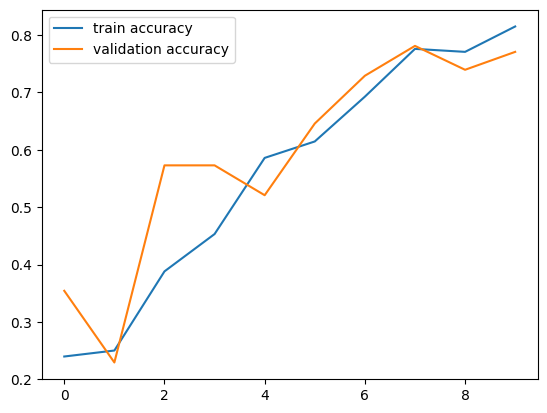

In [21]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],label='train accuracy')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.legend(); plt.show()